In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    weights=[0.85, 0.15],
    random_state=42
)
print("Total samples:", len(y))
print("Defaults (1):", y.sum())
print("Non-defaults (0):", (y==0).sum())

Total samples: 1000
Defaults (1): 152
Non-defaults (0): 848


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 800
Test samples: 200


In [4]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 3))

=== Classification Report ===
              precision    recall  f1-score   support

  No Default       0.98      0.96      0.97       168
     Default       0.81      0.91      0.85        32

    accuracy                           0.95       200
   macro avg       0.89      0.93      0.91       200
weighted avg       0.95      0.95      0.95       200

ROC-AUC Score: 0.983


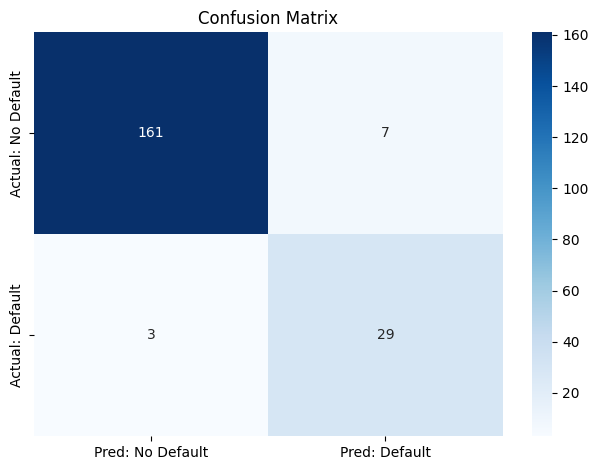

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest trained!")


Random Forest trained!


In [8]:
# Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_prob), 3))

=== Random Forest Results ===
              precision    recall  f1-score   support

  No Default       0.97      1.00      0.99       168
     Default       1.00      0.84      0.92        32

    accuracy                           0.97       200
   macro avg       0.99      0.92      0.95       200
weighted avg       0.98      0.97      0.97       200

ROC-AUC Score: 0.952


In [9]:
import pandas as pd

feature_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4', 'Feature 5']
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(fi_df)

     Feature  Importance
3  Feature 4    0.534707
1  Feature 2    0.196639
4  Feature 5    0.134418
0  Feature 1    0.101090
2  Feature 3    0.033146
